In [1]:
import numpy as np
from sklearn.datasets import load_iris

In [2]:
import matplotlib.pyplot as plt

In [3]:
data = load_iris()
X = data.data[:,[0,2]]

In [4]:
std = np.std(X,axis=0)
mean = np.mean(X,axis=0)

X = (X-mean)/std

In [5]:
def euclidean_distance(x1,x2):
  return np.sqrt(np.sum((x1 - x2)**2))

In [6]:
np.random.seed(42)

k =3

random_indices = np.random.choice(len(X),size=k,replace=False)

centroids = X[random_indices]

In [7]:
def assign_centroids(X, centroids):
  labels = []

  for x in X:
    distances = []
    for centroid in centroids:
      distance = euclidean_distance(x, centroid)
      distances.append(distance)

    val = np.argmin(distances)
    labels.append(val)
  return np.array(labels)

In [8]:
def update_centroids(X, labels, k):
  new_centroids = []

  for clusters in range(k):
    centroid_points = X[clusters == labels]
    print(centroid_points)
    new_centroid = np.mean(centroid_points,axis=0)
    new_centroids.append(new_centroid)
  return np.array(new_centroids)

In [9]:
max_iterations = 100
k=3
for iteration in range(max_iterations):
  labels = assign_centroids(X,centroids)
  print(labels)
  new_centroids = update_centroids(X, labels, k)
  print(new_centroids)
  if np.allclose(centroids,new_centroids):
    print(f"Convergence at {iteration}")
    break
  centroids = new_centroids

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 2 0 0 2 0 2 0 2 0
 0 0 0 0 0 0 2 2 0 0 0 2 0 0 2 0 0 0 2 2 2 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]
[[ 1.40150837  0.53540856]
 [ 0.67450115  0.42173371]
 [ 1.2803405   0.64908342]
 [-0.41600969  0.13754657]
 [ 0.79566902  0.47857113]
 [-0.17367395  0.42173371]
 [ 0.55333328  0.53540856]
 [ 0.91683689  0.47857113]
 [-0.7795133   0.08070915]
 [ 0.06866179  0.25122143]
 [ 0.18982966  0.13754657]
 [ 0.31099753  0.53540856]
 [-0.29484182 -0.08980313]
 [ 1.03800476  0.36489628]
 [-0.29484182  0.42173371]
 [-0.05250608  0.194384  ]
 [ 0.4321654   0.42173371]
 [-0.29484182  0.08070915]
 [ 0.06866179  0.59224599]
 [ 0.31099753  0.13754657]
 [ 0.55333328  0.64908342]
 [ 0.31099753  0.53540856]
 [ 0.67450115  0.30805885]
 [ 0.91683689  0.36489628]
 [ 1.15917263  0.59224599]
 [ 1.03800476  0.70

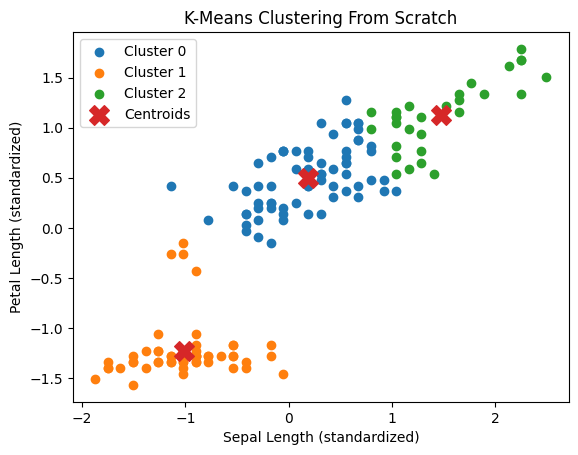

In [10]:
plt.figure()

for cluster in range(k):

    cluster_points = X[labels == cluster]

    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f"Cluster {cluster}")

plt.scatter(centroids[:, 0],centroids[:, 1],s=200,marker="X",label="Centroids")

plt.xlabel("Sepal Length (standardized)")
plt.ylabel("Petal Length (standardized)")

plt.title("K-Means Clustering From Scratch")

plt.legend()

plt.show()

